# Pipeline Check — verifying the preprocessing before training

Building a data pipeline is easy; building a *correct* one is not. Silent bugs
here are the expensive kind — the model trains, the loss goes down, and the
results are quietly meaningless. The classic failures:

- images normalised twice, or not at all → pixels in the wrong range
- labels misaligned with images after a shuffle → the model learns noise
- augmentation accidentally applied to validation → scores wobble, and the
  validation set stops measuring what it is supposed to
- augmentation silently doing nothing → no regularisation benefit at all

This notebook checks each of those **before** a single epoch is trained. Every
check prints an explicit PASS/FAIL rather than leaving it to the eye.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Make src/ importable from inside notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import (
    BATCH_SIZE,
    IMAGE_SIZE,
    build_augmentation,
    load_splits,
    summarise_splits,
)

FIGURES_DIR = PROJECT_ROOT / "notebooks" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow", tf.__version__)
print("Target image size:", IMAGE_SIZE, "| batch size:", BATCH_SIZE)

TensorFlow 2.21.0
Target image size: (128, 128) | batch size: 32


## 1. The split is stratified

Each split should preserve the overall class distribution. If the `%` columns
match across train/val/test, stratification worked.

In [2]:
summarise_splits()

,train,val,test,total,train_%,val_%,test_%
label,,,,,,,
Tomato_Yellow_Leaf_Curl_Virus,3750,803,804,5357,29.5,29.5,29.5
Bacterial_spot,1489,319,319,2127,11.7,11.7,11.7
Late_blight,1336,287,286,1909,10.5,10.5,10.5
Septoria_leaf_spot,1240,266,265,1771,9.8,9.8,9.7
Spider_mites Two-spotted_spider_mite,1173,251,252,1676,9.2,9.2,9.3
healthy,1114,239,238,1591,8.8,8.8,8.7
Target_Spot,983,210,211,1404,7.7,7.7,7.7
Early_blight,700,150,150,1000,5.5,5.5,5.5
Leaf_Mold,666,143,143,952,5.2,5.2,5.2


In [3]:
counts = summarise_splits()

print("Split sizes:")
for name in ("train", "val", "test"):
    print(f"  {name:>5}: {counts[name].sum():>6,} images "
          f"({counts[name].sum() / counts['total'].sum():.0%})")

print("\nImbalance ratio (largest / smallest class):")
for name in ("train", "val", "test"):
    print(f"  {name:>5}: {counts[name].max() / counts[name].min():.1f}x")

# The strongest single check: the biggest percentage-point gap between any
# class's share in one split versus another.
shares = counts[["train_%", "val_%", "test_%"]]
max_drift = (shares.max(axis=1) - shares.min(axis=1)).max()
print(f"\nLargest class-share drift between splits: {max_drift:.1f} percentage points")
print("PASS - stratification held" if max_drift < 1.0 else "FAIL - splits drifted apart")

Split sizes:
  train: 12,712 images (70%)
    val:  2,724 images (15%)
   test:  2,724 images (15%)

Imbalance ratio (largest / smallest class):
  train: 14.4x
    val: 14.3x
   test: 14.4x

Largest class-share drift between splits: 0.1 percentage points
PASS - stratification held


## 2. Load one batch from each split

Checking shape and dtype. Expected shape is
`(batch, height, width, channels)` = `(32, 128, 128, 3)`.

In [4]:
# augment_train=False here so this batch is directly comparable to val/test.
train_ds, val_ds, test_ds, class_names = load_splits(augment_train=False)

print("Classes (index -> name):")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

batches = {}
for split_name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    images, labels = next(iter(ds))
    batches[split_name] = (images.numpy(), labels.numpy())
    print(f"\n{split_name}:")
    print(f"  images {images.shape} {images.dtype}")
    print(f"  labels {labels.shape} {labels.dtype}")

Classes (index -> name):
  0: Bacterial_spot
  1: Early_blight
  2: Late_blight
  3: Leaf_Mold
  4: Septoria_leaf_spot
  5: Spider_mites Two-spotted_spider_mite
  6: Target_Spot
  7: Tomato_Yellow_Leaf_Curl_Virus
  8: Tomato_mosaic_virus
  9: healthy

train:
  images (32, 128, 128, 3) <dtype: 'float32'>
  labels (32,) <dtype: 'int32'>



val:
  images (32, 128, 128, 3) <dtype: 'float32'>
  labels (32,) <dtype: 'int32'>

test:
  images (32, 128, 128, 3) <dtype: 'float32'>
  labels (32,) <dtype: 'int32'>


In [5]:
expected = (BATCH_SIZE, *IMAGE_SIZE, 3)
all_ok = True

for split_name, (images, labels) in batches.items():
    shape_ok = images.shape == expected
    label_ok = labels.shape == (BATCH_SIZE,)
    all_ok &= shape_ok and label_ok
    print(f"{split_name:>5}: shape {images.shape} "
          f"{'OK' if shape_ok else 'MISMATCH, expected ' + str(expected)}")

print("\nPASS - all splits produce correctly shaped batches" if all_ok else "\nFAIL")

train: shape (32, 128, 128, 3) OK
  val: shape (32, 128, 128, 3) OK
 test: shape (32, 128, 128, 3) OK

PASS - all splits produce correctly shaped batches


## 3. Pixel values are normalised to [0, 1]

The pipeline divides by 255. If the minimum is 0-ish and the maximum is 1-ish,
normalisation ran exactly once. A max around 255 means it never ran; a max
around 0.004 means it ran twice.

In [6]:
all_ok = True

for split_name, (images, _) in batches.items():
    lo, hi, mean = images.min(), images.max(), images.mean()
    in_range = 0.0 <= lo and hi <= 1.0 and hi > 0.5   # >0.5 rules out double-scaling
    all_ok &= in_range
    print(f"{split_name:>5}: min={lo:.4f}  max={hi:.4f}  mean={mean:.4f}  "
          f"{'OK' if in_range else 'OUT OF RANGE'}")

print("\nPASS - pixels normalised to [0, 1] exactly once" if all_ok
      else "\nFAIL - check the /255.0 step")

train: min=0.0000  max=0.9510  mean=0.4376  OK
  val: min=0.0000  max=0.9578  mean=0.4308  OK
 test: min=0.0000  max=0.9657  mean=0.4373  OK

PASS - pixels normalised to [0, 1] exactly once


## 4. Labels line up with images

The check that catches the worst bug of all. If images and labels came apart
during shuffling, the model would train on noise while the loss curve still
looked plausible.

Below: 10 validation images, one per class, each titled with the label the
pipeline assigned it. A healthy leaf should look healthy; a mosaic-virus leaf
should show yellow mottling. This is a check only a human can sign off.

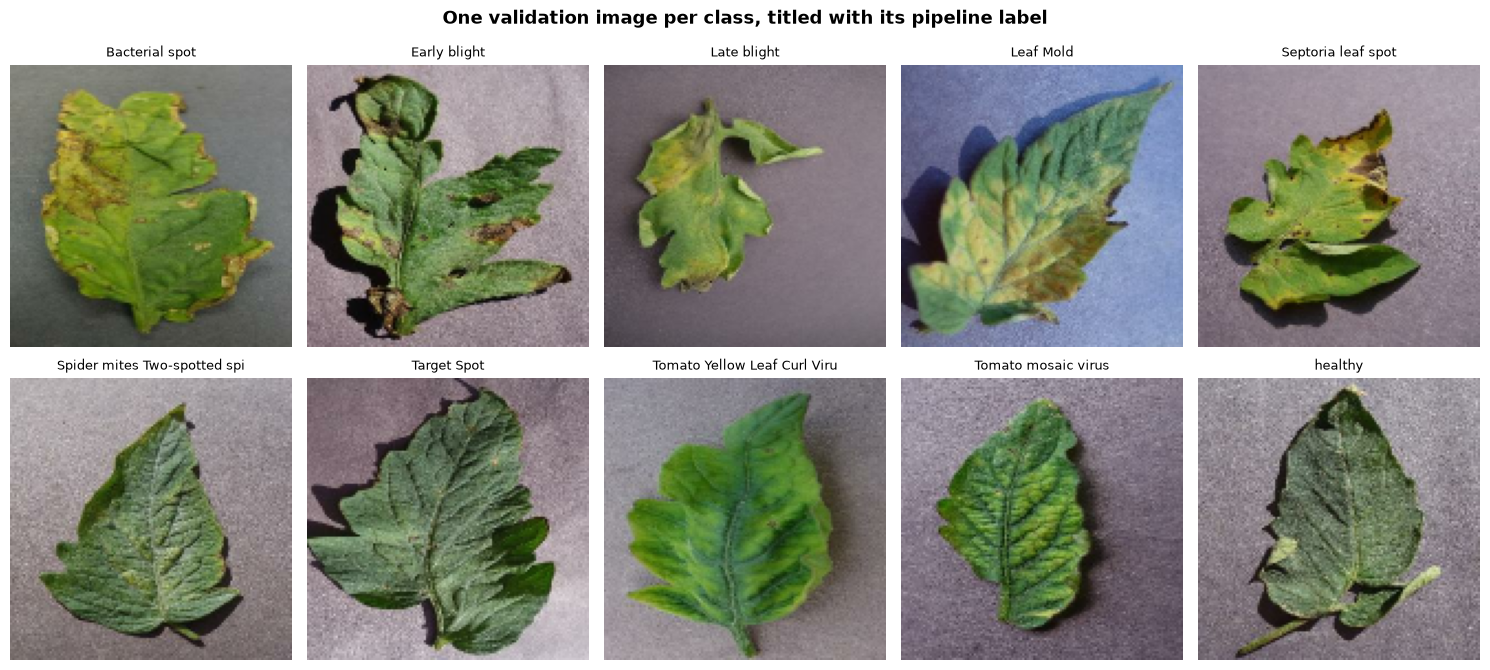

In [7]:
# Collect one example of each class from the validation set.
examples = {}
for images, labels in val_ds:
    for image, label in zip(images.numpy(), labels.numpy()):
        name = class_names[label]
        if name not in examples:
            examples[name] = image
    if len(examples) == len(class_names):
        break

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for ax, name in zip(axes.ravel(), class_names):
    ax.imshow(examples[name])
    ax.set_title(name.replace("_", " ")[:28], fontsize=9)
    ax.axis("off")

fig.suptitle("One validation image per class, titled with its pipeline label",
             fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "label_alignment_check.png", bbox_inches="tight")
plt.show()

In [8]:
# Every label index must map into the class list, and across a few batches we
# should see a good spread of classes rather than one repeated value.
seen = []
for i, (_, labels) in enumerate(val_ds):
    seen.extend(labels.numpy().tolist())
    if i >= 9:
        break

seen = np.array(seen)
in_bounds = seen.min() >= 0 and seen.max() < len(class_names)
variety = len(np.unique(seen))

print(f"Label index range: {seen.min()} to {seen.max()} "
      f"(valid range 0 to {len(class_names) - 1})")
print(f"Distinct classes seen across {len(seen)} samples: {variety}/{len(class_names)}")
print("\nPASS - labels are valid indices with good variety"
      if in_bounds and variety >= 8 else "\nFAIL")

Label index range: 0 to 9 (valid range 0 to 9)
Distinct classes seen across 320 samples: 10/10

PASS - labels are valid indices with good variety


## 5. Augmentation is visibly working on training data

Each row below is **the same source image** passed through the augmentation
layers five times. The variants should differ visibly — flipped, slightly
rotated, slightly zoomed — while remaining obviously the same leaf and the same
disease.

That last point is the design constraint: augmentation must change the image
without ever changing what the correct answer is.

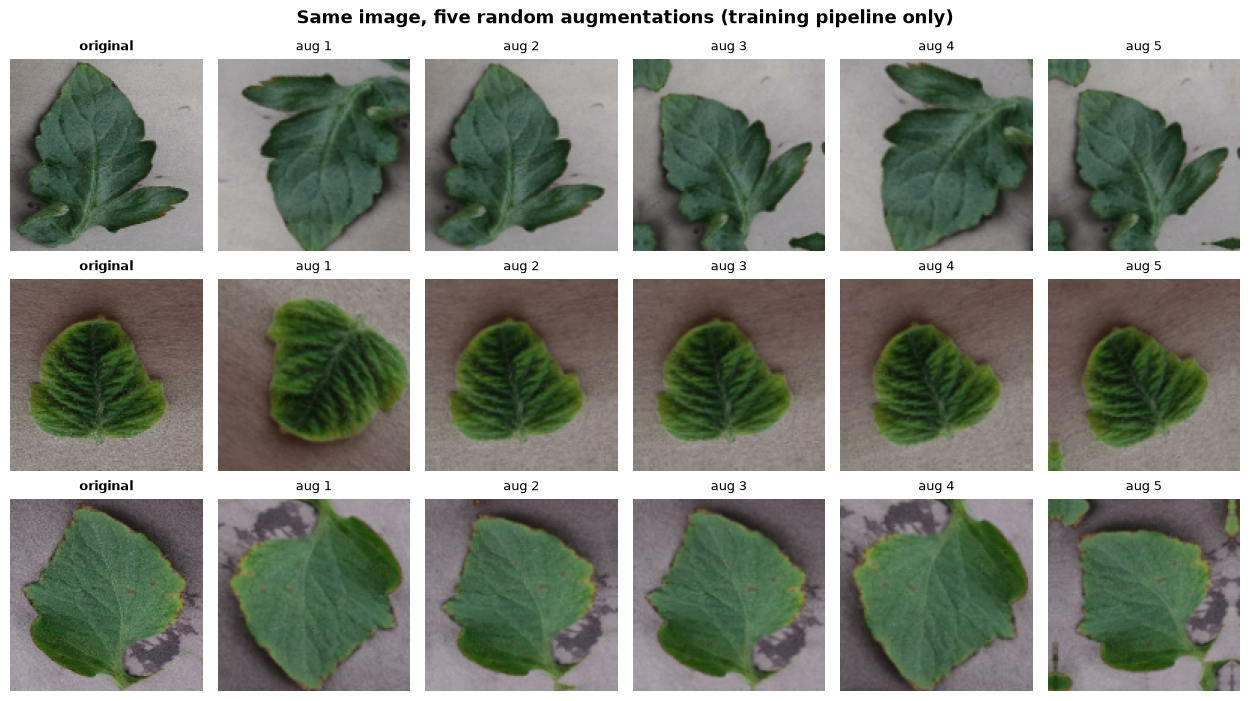

In [9]:
augmentation = build_augmentation()

# Take three source images from the *unaugmented* training batch.
train_images, train_labels = batches["train"]
source_indices = [0, 1, 2]
n_variants = 5

fig, axes = plt.subplots(len(source_indices), n_variants + 1,
                         figsize=((n_variants + 1) * 2.1, len(source_indices) * 2.4))

for row, idx in enumerate(source_indices):
    original = train_images[idx]
    label_name = class_names[train_labels[idx]]

    axes[row, 0].imshow(original)
    axes[row, 0].set_title("original", fontsize=9, weight="bold")
    axes[row, 0].axis("off")

    for col in range(n_variants):
        # training=True is essential -- these layers are no-ops otherwise.
        variant = augmentation(np.expand_dims(original, 0), training=True)[0]
        axes[row, col + 1].imshow(np.clip(variant, 0, 1))
        axes[row, col + 1].set_title(f"aug {col + 1}", fontsize=9)
        axes[row, col + 1].axis("off")

    axes[row, 0].set_ylabel(label_name, fontsize=8)

fig.suptitle("Same image, five random augmentations (training pipeline only)",
             fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "augmentation_check.png", bbox_inches="tight")
plt.show()

In [10]:
# Quantitative version of the same check: augmented output must differ from the
# input, but not so wildly that the image is unrecognisable.
original = train_images[:8]
variant_a = augmentation(original, training=True).numpy()
variant_b = augmentation(original, training=True).numpy()

diff_from_original = np.abs(variant_a - original).mean()
diff_between_variants = np.abs(variant_a - variant_b).mean()

print(f"Mean |augmented - original| : {diff_from_original:.4f}")
print(f"Mean |variant A - variant B|: {diff_between_variants:.4f}")

changed = diff_from_original > 0.01
random = diff_between_variants > 0.01
print("\nPASS - augmentation alters images" if changed else "\nFAIL - augmentation is a no-op")
print("PASS - augmentation is random per call" if random
      else "FAIL - same output every time (not random)")

Mean |augmented - original| : 0.1206
Mean |variant A - variant B|: 0.0937

PASS - augmentation alters images
PASS - augmentation is random per call


## 6. Validation and test data are NOT augmented

The most important check in this notebook. Validation exists to estimate
performance on real, untouched images. If augmentation leaked into it, the score
would measure the model on distorted inputs no user will ever submit, and would
jitter from run to run as the random distortions changed.

The test: iterate the validation set twice and compare. Without augmentation the
two passes must be **bit-for-bit identical**.

In [11]:
# load_splits with augment_train=True is the configuration training actually
# uses -- so this tests the real pipeline, not a special-cased one.
train_aug_ds, val_ds_2, test_ds_2, _ = load_splits(augment_train=True)

first_pass = next(iter(val_ds_2))[0].numpy()
second_pass = next(iter(val_ds_2))[0].numpy()
identical = np.array_equal(first_pass, second_pass)

print(f"Validation, two passes -> identical: {identical}")
print(f"Max absolute difference: {np.abs(first_pass - second_pass).max():.10f}")
print("PASS - validation data is deterministic and unaugmented" if identical else "FAIL")

test_first = next(iter(test_ds_2))[0].numpy()
test_second = next(iter(test_ds_2))[0].numpy()
test_identical = np.array_equal(test_first, test_second)
print(f"\nTest, two passes -> identical: {test_identical}")
print("PASS - test data is deterministic and unaugmented" if test_identical else "FAIL")

Validation, two passes -> identical: True
Max absolute difference: 0.0000000000
PASS - validation data is deterministic and unaugmented

Test, two passes -> identical: True
PASS - test data is deterministic and unaugmented


In [12]:
# And the mirror image: the training pipeline SHOULD differ between passes,
# because augmentation is random and shuffling is on.
train_first = next(iter(train_aug_ds))[0].numpy()
train_second = next(iter(train_aug_ds))[0].numpy()
train_differs = not np.array_equal(train_first, train_second)

print(f"Training, two passes -> differ: {train_differs}")
print("PASS - training data is augmented and reshuffled each pass" if train_differs
      else "FAIL - training pipeline looks static")

Training, two passes -> differ: True
PASS - training data is augmented and reshuffled each pass


## 7. Summary

| Check | What it protects against |
|---|---|
| Stratified split | Rare classes under-represented in val/test, making their scores noise |
| Batch shape `(32, 128, 128, 3)` | Silent resize failures; shape errors surfacing only at `model.fit` |
| Pixels in `[0, 1]` | Normalising twice or not at all — both cripple training |
| Labels valid and visually correct | Images and labels coming apart during shuffling |
| Augmentation alters + randomises | Augmentation silently doing nothing, giving no regularisation |
| Val/test bit-for-bit identical across passes | Augmentation leaking into evaluation and corrupting the metric |

With every check passing, the pipeline is safe to train on in Phase 4.